In [108]:
from importlib.metadata import version
print(version("matplotlib"))
print(version("numpy"))
print(version("tiktoken"))
print(version("torch"))
print(version("tensorflow"))


3.10.9
2.4.4
0.12.0
2.11.0
2.21.0


In [109]:
import torch
from model import GPTModel


GPT_CONFIG_124M = {
    "vocab_size": 50257, 
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12, 
    "n_layers": 12,
    "drop_rate": 0.1, 
    "qkv_bias": False, 
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [ ]:
import tiktoken
from model import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special = {"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

start_context = "Every Effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size = GPT_CONFIG_124M["context_length"],
)

print(token_ids_to_text(token_ids, tokenizer))


Every Effort moves you finisheduxeHandle appropriation pigment Primordial Dying counsellingilibriumolve


In [111]:
#Example inputs/targets

inputs = torch.tensor([[16833, 3626, 6100],  
                       [40,    1107, 588]])   

targets = torch.tensor([[3626, 6100, 345  ], 
                        [1107,  588, 11311]]) 

with torch.no_grad():
    logits = model(inputs)

probabilities = torch.softmax(logits, dim = -1)
print(probabilities.shape)

token_ids = torch.argmax(probabilities, dim = -1, keepdim = True)
print(token_ids)

print(token_ids_to_text(targets[0], tokenizer))
print(token_ids_to_text(targets[1], tokenizer))


#Identify what the correct token is at each position
text_idx = 0
target_probabilities_1 = probabilities[text_idx, [0,1,2], targets[text_idx]]
print(target_probabilities_1)


text_idx = 1
target_probabilities_2 = probabilities[text_idx, [0,1,2], targets[text_idx]]
print(target_probabilities_2)



torch.Size([2, 3, 50257])
tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])
 effort moves you
 really like chocolate
tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])
tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [112]:
log_probabilities = torch.log(torch.cat((target_probabilities_1, target_probabilities_2)))
print(log_probabilities)

avg_log_probabilities = torch.mean(log_probabilities)
print(avg_log_probabilities)

neg_avg_log_probabilities = avg_log_probabilities * -1

logits_flat = logits.flatten(0,1)
targets_flat = targets.flatten()

print(logits.shape, targets.shape)
print(logits_flat.shape, targets_flat.shape)

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)
perplexity = torch.exp(loss)
print(perplexity)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])
tensor(-10.7940)
torch.Size([2, 3, 50257]) torch.Size([2, 3])
torch.Size([6, 50257]) torch.Size([6])
tensor(10.7940)
tensor(48725.8203)


In [113]:
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding = "utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding = "utf-8") as file:
        text_data = file.read()


total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print(total_characters, total_tokens)

20479 5145


In [114]:
from model import create_dataloader_v1

train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data, 
    batch_size = 2,
    max_length = GPT_CONFIG_124M["context_length"],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last = True,
    shuffle = True,
    num_workers = 0
)

val_loader = create_dataloader_v1(
    val_data, 
    batch_size = 2,
    max_length = GPT_CONFIG_124M["context_length"],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last = False,
    shuffle = False,
    num_workers = 0
)

In [115]:
for x,y in train_loader:
    print(x.shape, y.shape)

torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])


In [116]:
def calc_loss_batch(input_batch, target_batch, model, device):
    """
    Calculates Cross Entropy Loss of a batch
    Args:
        input_batch: torch.Tensor
        target_batch: torch.Tensor
        model: torch.nn.Module
        device: torch.device
    Returns
    Loss:
        torch.Tensor
    """
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0,1), target_batch.flatten())
    return loss

def calc_loss_loader(data_loader, model, device, num_batches = None):
    total_loss = 0. 
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))


    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    
    return total_loss / num_batches

In [117]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2,9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print(device)

model.to(device)

torch.manual_seed(123)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)


print(train_loss)
print(val_loss)


mps
10.987583054436577
10.98110580444336


TRAINING

In [118]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    """
    Trains the Model
    Args:
        model: (torch.nn.Module)
        train_loader: (torch.utilis.data.DataLoader)
        val_loader: (torch.utilis.data.DataLoader)
        optimizer: (torch Optimizer)
        device: (torch.device)
        num_epochs: (int)
        eval_freq: (int)
        eval_iter: (int)
        start_context: (str)
        tokenizer: tokenizer
    Returns:
        list, list, list (train_losses, val_losses, track_tokens_seen)

    """
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, 1


    #Main Training Pipeline
    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Epoch {epoch + 1} (Step {global_step:06d}): train loss {train_loss:.3f}, val loss {val_loss:.3f} ")

        generate_and_print_sample(model, tokenizer, device, start_context)
    
    return train_losses, val_losses, track_tokens_seen 
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    """
    testing for train and validation losses
    Args:
        model
        train_loader
        val_loader
        device
        eval_iter
    Returns:
        train_loss
        val_loss
    """
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches = eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches = eval_iter)
    model.train()
    return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(model = model, idx = encoded, max_new_tokens = 50, context_size = context_size)
    
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " " ))
    model.train()






In [119]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs=num_epochs, eval_freq = 5, eval_iter = 5, start_context = "Every Effort moves you", tokenizer = tokenizer)

Epoch 1 (Step 000005): train loss 8.833, val loss 8.888 
Epoch 1 (Step 000010): train loss 7.186, val loss 7.465 
Every Effort moves you,,,,,,,,,,,,,.                                    
Epoch 2 (Step 000015): train loss 6.190, val loss 6.693 
Every Effort moves you,,, and,, and,,,, and, and,,,,,,,,,,, and,, the,, the, and,, and,,, the, and,,,,,, and
Epoch 3 (Step 000020): train loss 5.885, val loss 6.520 
Epoch 3 (Step 000025): train loss 5.658, val loss 6.523 
Every Effort moves you his! his and the picture, and, and, and, and, and, and, and, and, and, and, and the of the the of the of the! the!, and, and, and, and, and,
Epoch 4 (Step 000030): train loss 5.484, val loss 6.500 
Epoch 4 (Step 000035): train loss 5.215, val loss 6.411 
Every Effort moves you know, and and the picture, and his the picture.                                      
Epoch 5 (Step 000040): train loss 5.000, val loss 6.325 
Epoch 5 (Step 000045): train loss 4.283, val loss 6.279 
Every Effort moves you       "II

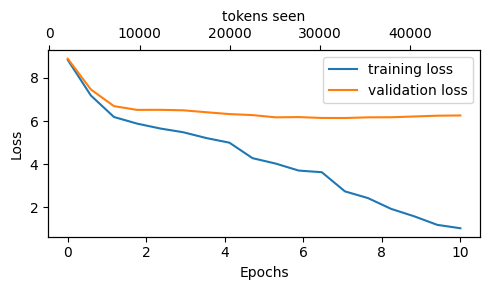

In [120]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5,3))
    ax1.plot(epochs_seen, train_losses, label = "training loss")
    ax1.plot(epochs_seen, val_losses, label = "validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc = "upper right")


    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha = 0)
    ax2.set_xlabel("tokens seen")

    fig.tight_layout()
    plt.savefig("loss")

    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [121]:
inference_device = torch.device("cpu")

model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens = 25,
    context_size = GPT_CONFIG_124M["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you?"
"I that my hostess was "interesting": on the last word. Gisburn's an awful simpleton


In [122]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

# Suppose input is "every effort moves you", and the LLM
# returns the following logits for the next token:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()

# The next generated token is then as follows:
print(inverse_vocab[next_token_id])

torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples = 1).item()
print(inverse_vocab[next_token_id])


forward
forward


In [123]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples = 1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength = len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


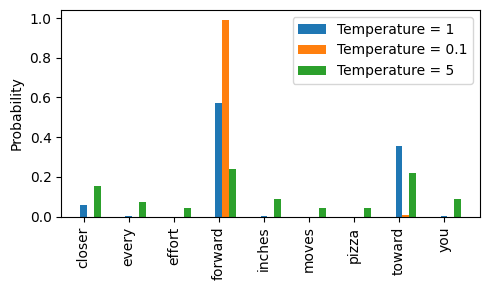

In [124]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim = 0)


temperatures = [1,0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize = (5,3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label = f'Temperature = {T}')

ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation = 90)
ax.legend()
plt.tight_layout()
plt.savefig("Temperature-plots.pdf")
plt.show()

In [125]:
#Top k 
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print(next_token_logits)
print(top_logits)
print(top_pos)

new_logits = torch.where(
    condition = next_token_logits < top_logits[-1],
    input = torch.tensor(float("-inf")),
    other = next_token_logits
)
print(new_logits)

topk_probas = torch.softmax(new_logits, dim = 0)
print(topk_probas)

tensor([ 4.5100,  0.8900, -1.9000,  6.7500,  1.6300, -1.6200, -1.8900,  6.2800,
         1.7900])
tensor([6.7500, 6.2800, 4.5100])
tensor([3, 7, 0])
tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [129]:
def generate(model, idx, max_new_tokens, context_size, temperature = 0.0, top_k = None, eos_id = None):
    for _ in range(max_new_tokens):

        idx_cond = idx[:, -context_size:]

        #call the forward pass of GPTMODEL such that input enters model 
        with torch.no_grad():
            logits = model(idx_cond) 
        logits = logits[:, -1, :]

        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)
        

        if temperature > 0.0:
            logits = logits/temperature

            logits = logits - logits.max(dim = -1, keepdim = True).values
            #the probability is just softmax of raw scores
            probabilities = torch.softmax(logits, dim = -1)

            idx_next = torch.multinomial(probabilities, num_samples = 1)            

        else:
            idx_next = torch.argmax(logits, dim = -1, keepdim = True)

        if idx_next == eos_id:
            break 
        idx = torch.cat((idx, idx_next), dim = 1)
    
    return idx


In [130]:
torch.manual_seed(123)

token_ids = generate(
    model = model,
    idx = text_to_token_ids("Every Effort moves you", tokenizer).to(inference_device),
    max_new_tokens=15, 
    context_size = GPT_CONFIG_124M["context_length"],
    top_k = 25,
    temperature = 1.4
)

print(token_ids_to_text(token_ids, tokenizer))

Every Effort moves you he never on his life. Th is to have "I quoteanim by


In [131]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)